In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data=pd.read_csv(r"C:\Users\weelcome\Downloads\Airbnb NYC 2019.csv")
data.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [17]:
print(data.info())
print(data.isnull().sum())
print(data.shape)
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

##APPROACH TO PROCEED WITH EDA 
1. Handle duplicates 
2. Handle missing values
3. Identify Categorical Features and convert them into numerical features
4. Visualize and draw plots to identify outliers
5. log transformations
6. feature scaling




In [18]:
data.drop_duplicates()
#print out important info about the data
print(data.info())
print(data.shape)
print('Columns of the dataframe are=\n',data.columns)
print(data.describe().T)
print(data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [19]:
#HANDLING NULL VALUES
#we see there are null values in name and host_id respectively. We cant really replace these with anything else except 'unknown or anonymous'

print(data[data['name'].isnull()]) #to print those records whose name is NaN
data['name']=data['name'].fillna('Anonymous') #replace all the Nan with anonymous
print(data['name'].isnull().sum())#check the no of NAN now == 0

print(data[data['host_name'].isnull()]) #to print those records whose host_id is NaN
data['host_name']=data['host_name'].fillna('unknown')
print(data['host_name'].isnull().sum())

#print(data.isnull().sum())
#now the dataset has 0 NaNs in name and host_id
#print(data[data['last_review'].isnull()])
#Last Review is not that important so we drop it 

data.drop(['last_review'],axis=1,inplace=True)
data['reviews_per_month']=data['reviews_per_month'].fillna(value=0)
data['reviews_per_month'].isnull().sum() #now we have zero NaNs
print(data.isnull().sum()) #no null values 
data.head()

             id name   host_id host_name neighbourhood_group  \
2854    1615764  NaN   6676776     Peter           Manhattan   
3703    2232600  NaN  11395220      Anna           Manhattan   
5775    4209595  NaN  20700823     Jesse           Manhattan   
5975    4370230  NaN  22686810   Michaël           Manhattan   
6269    4581788  NaN  21600904     Lucie            Brooklyn   
6567    4756856  NaN   1832442  Carolina            Brooklyn   
6605    4774658  NaN  24625694      Josh           Manhattan   
8841    6782407  NaN  31147528  Huei-Yin            Brooklyn   
11963   9325951  NaN  33377685  Jonathan           Manhattan   
12824   9787590  NaN  50448556    Miguel           Manhattan   
13059   9885866  NaN  37306329  Juliette           Manhattan   
13401  10052289  NaN  49522403   Vanessa            Brooklyn   
15819  12797684  NaN  69715276       Yan           Manhattan   
16071  12988898  NaN  71552588    Andrea               Bronx   
18047  14135050  NaN  85288337      Jeff

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [20]:
#CATEGORICAL VARIABLES ARE-NEIGHNOURHOOD_GROUP,ROOM TYPE

data['neighbourhood_group'].unique()
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['neighbourhood_group_encoded'] = label_encoder.fit_transform(data['neighbourhood_group'])
data = data.drop(['neighbourhood_group'], axis=1)
data.head()


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_encoded
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,2
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,2


In [10]:
data['room_type'].unique()
data1=pd.get_dummies(data['room_type'])
data1.head()
data=pd.concat([data,data1],axis=1)
data.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_encoded,Entire home/apt,Private room,Shared room
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1,False,True,False
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,2,True,False,False
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365,2,False,True,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,True,False,False
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,2,True,False,False


In [11]:
data.drop(['room_type'],axis=1,inplace=True)


In [15]:
data.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_encoded,Entire home/apt,Private room,Shared room
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,149,1,9,0.21,6,365,1,False,True,False
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,225,1,45,0.38,2,355,2,True,False,False
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,150,3,0,0.00,1,365,2,False,True,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,89,1,270,4.64,1,194,1,True,False,False
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,80,10,9,0.10,1,0,2,True,False,False


(0.0, 80000.0)

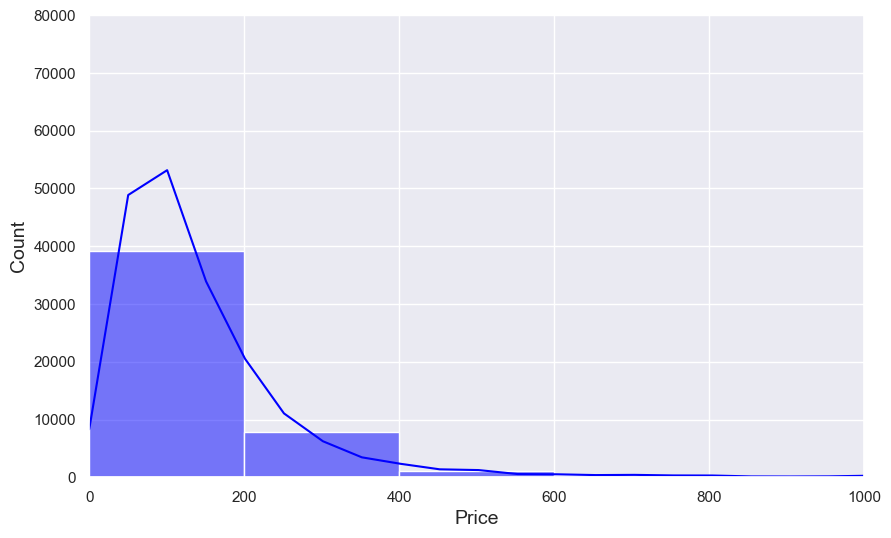

In [51]:
#visualize by drawing plots
plt.figure(figsize=(10, 6))

# Plot a histogram of prices
sns.histplot(data['price'], bins=50, kde=True, color='blue')

# Add labels and title
plt.xlabel('Price', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xlim(0,1000
        )
plt.ylim(0,80000)

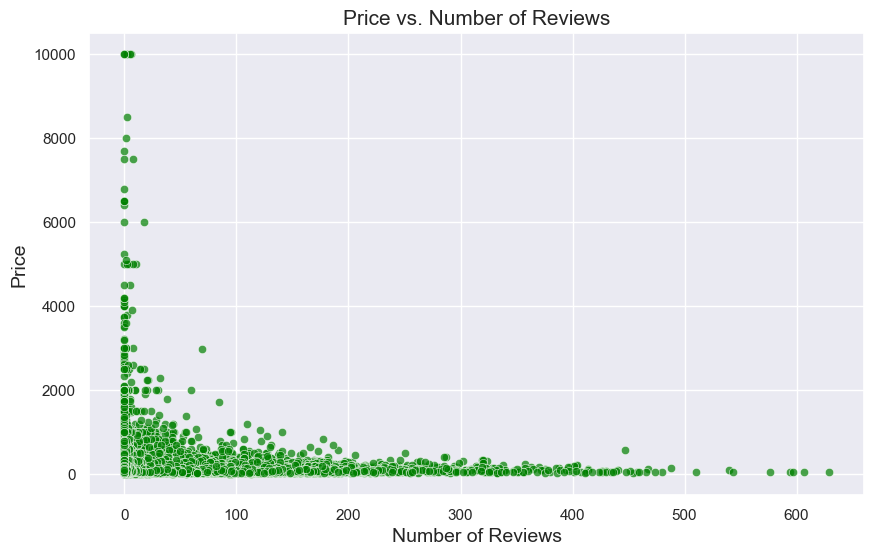

In [48]:
# Create a figure with a custom size
plt.figure(figsize=(10, 6))

# Plot a scatter plot of price vs. number_of_reviews
sns.scatterplot(x='number_of_reviews', y='price', data=data, alpha=0.7, color='green')

# Add labels and title
plt.xlabel('Number of Reviews', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.title('Price vs. Number of Reviews', fontsize=15)

plt.show()


Text(0.5, 1.0, 'Listings by Top Neighborhoods in NYC')

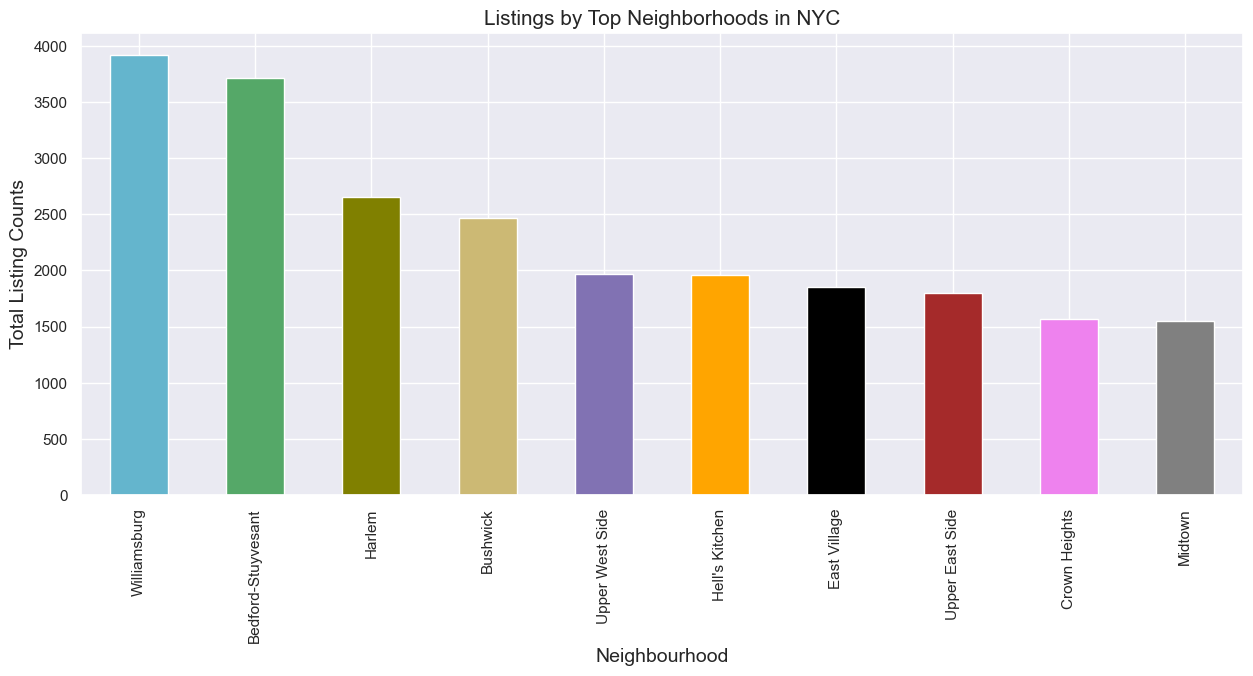

In [55]:
top_10_neigbourhoods = data['neighbourhood'].value_counts().nlargest(10)

# Create a list of colors to use for the bars
colors = ['c', 'g', 'olive', 'y', 'm', 'orange', 'black', 'brown', 'violet', 'gray']

# Create a bar plot of the top 10 neighborhoods using the specified colors
top_10_neigbourhoods.plot(kind='bar', figsize=(15, 6), color = colors)

# Set the x-axis label
plt.xlabel('Neighbourhood', fontsize=14)

# Set the y-axis label
plt.ylabel('Total Listing Counts', fontsize=14)

# Set the title of the plot
plt.title('Listings by Top Neighborhoods in NYC', fontsize=15)


<Axes: xlabel='price'>

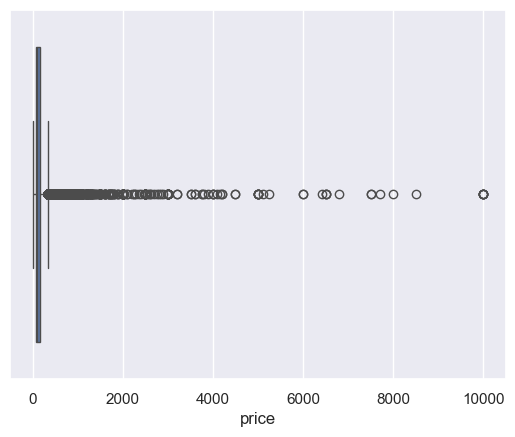

In [56]:
sns.boxplot(x=data['price'])


Number of outliers removed: 2972
(48895, 15)


<Axes: xlabel='price'>

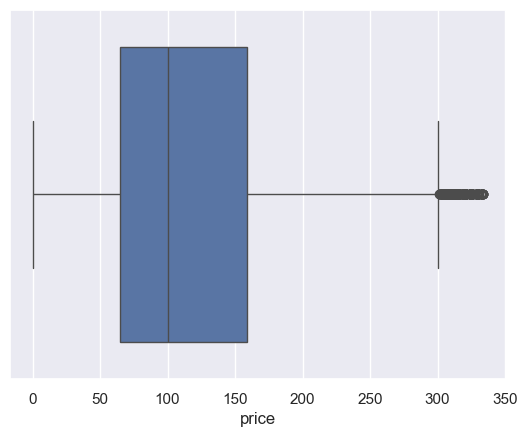

In [61]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

# Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_filtered = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]

# Optionally, you can check how many outliers were removed
outliers_removed = data.shape[0] - df_filtered.shape[0]
print(f'Number of outliers removed: {outliers_removed}')
print(data.shape)

sns.boxplot(x=df_filtered['price'])


<Axes: xlabel='log_price', ylabel='Count'>

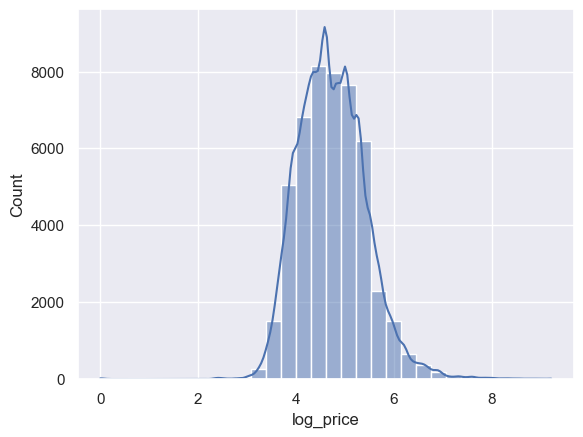

In [63]:
data['log_price'] = np.log1p(data['price']) 
sns.histplot(data['log_price'],kde=True,bins=30)